# Approximate Hybrid Quantum State Preparation for a PPG Signal

## Imports

In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import numpy as np
import pandas as pd
import os
import math
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

## PPG Signal Loading

A sample PPG signal is loaded from the `ppg_dataset/` directory for hybrid quantum reconstruction experiments.

In [3]:
signal = np.load(
    "../ppg-dataset/ppg_sample.npy"
)

target_f = (
    signal /
    np.linalg.norm(signal)
)

### Visualization of Signal

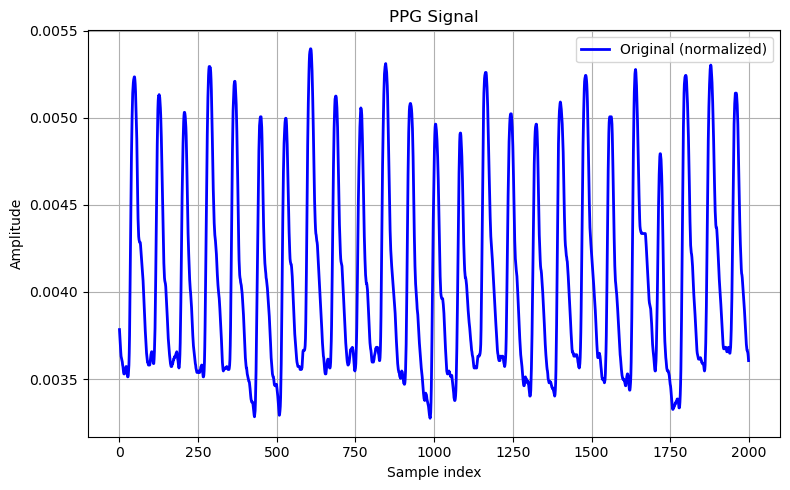

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(target_f[:2000], label="Original (normalized)", lw=2, color="blue")

plt.title(f"PPG Signal")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

## Phase I: Compression of the Piecewise Constant Signal
### Classical Sparsity Analysis

The transform-domain coefficients are analyzed in order to identify sparse representations suitable for quantum state preparation.

In [5]:
results = search_sparse_haar_representations(
    signal,
    tolerance=0.04
)

Level=8 | Threshold=8.793e-03 | Nonzero=20847 | Sparsity=0.318 | Trace Distance=5.844550e-03 | Fidelity=0.999966
Level=8 | Threshold=1.759e-02 | Nonzero=13898 | Sparsity=0.212 | Trace Distance=1.090539e-02 | Fidelity=0.999881
Level=8 | Threshold=4.397e-02 | Nonzero=7027 | Sparsity=0.107 | Trace Distance=2.335219e-02 | Fidelity=0.999455
Level=8 | Threshold=8.793e-02 | Nonzero=3849 | Sparsity=0.059 | Trace Distance=3.898391e-02 | Fidelity=0.998480
Level=9 | Threshold=1.194e-02 | Nonzero=17196 | Sparsity=0.262 | Trace Distance=7.822391e-03 | Fidelity=0.999939
Level=9 | Threshold=2.389e-02 | Nonzero=10768 | Sparsity=0.164 | Trace Distance=1.435047e-02 | Fidelity=0.999794
Level=9 | Threshold=5.972e-02 | Nonzero=5181 | Sparsity=0.079 | Trace Distance=2.902260e-02 | Fidelity=0.999158
Level=10 | Threshold=1.590e-02 | Nonzero=13867 | Sparsity=0.212 | Trace Distance=1.027680e-02 | Fidelity=0.999894
Level=10 | Threshold=3.179e-02 | Nonzero=8427 | Sparsity=0.129 | Trace Distance=1.795212e-02 | Fid

In [6]:
# Apply 10-level discrete packet Haar wavelet transformation on sinc signal
level = 13
X = haar_packet_transform(signal, level)

In [7]:
# apply top-k threshold on the transformed data for k =110

k = 3000
Xr = top_k_threshold(X, k)

### Normalization

In [8]:
X_norm = Xr/np.linalg.norm(Xr)

### Classical Signal Reconstruction

In [9]:
x_rec = inverse_haar_packet_transform(X_norm, level)

### Trace Distance

In [10]:
TD = trace_distance(x_rec, target_f)

### Visualization

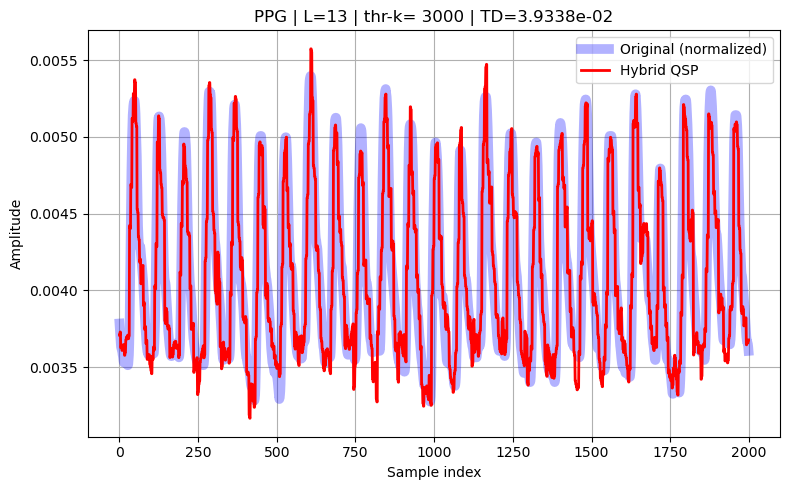

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(target_f[:2000], 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(x_rec[:2000], lw=2, color="red", label="Hybrid QSP")
plt.title(f"PPG | L={level} | thr-k= {k} | TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();

plt.savefig("../figures/PPG_signal_preparation.pdf")
plt.show()

## Phase II: Quantum Decompression
The sparse Haar-domain representation is normalized and encoded into a quantum state. The inverse Quantum Packet Haar Wavelet Transform is then applied in order to reconstruct the original signal quantum mechanically.

In [12]:
from qibo import Circuit, gates
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [13]:
# Sparse transform-domain coefficient vector
vec = X_norm

# Indices of nonzero coefficients
nz = np.flatnonzero(vec)

# Total number of qubits required
# for amplitude encoding
nqubits = int(np.log2(len(vec)))

# Construct sparse basis-state representation
# as (bitstring, amplitude) pairs
y = [
    (format(i, f"0{nqubits}b"), vec[i])
    for i in nz
]

# Prepare sparse quantum state using
# the Farias SQSP method
qc = sparse_encoder(
    y,
    method="farias"
)

# Construct inverse quantum Haar packet
# wavelet transform circuit
iqphwt = build_inverse_qphwt_circuit(
    n=nqubits,
    level=level
)

# Apply inverse quantum transformation
# for signal reconstruction
qc.add(
    iqphwt.on_qubits(*range(nqubits))
)

# Display decomposed circuit statistics
# for quantum resource analysis
print(
    qc.decompose().decompose().summary()
)

[Qibo 0.3.3|INFO|2026-05-28 12:34:51]: Using numpy backend on /CPU:0


Circuit depth = 22912
Total number of gates = 32061
Number of qubits = 16
Most common gates:
cx: 16257
x: 9036
ry: 6715
h: 53
None


## Statevector of the Quantum SQSP and Quantum Decompression

In [ ]:
result = qc()

state = result.state()

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(target_f[:2000], 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(state.real[:2000], lw=2, color="red", label="Hybrid QSP")
plt.title(f"PPG Signal | L={level} | thr-k={k} |  TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()